# Pavan S (24BAD085)

# SVD Recommendation System


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

In [2]:
url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
df = pd.read_csv(url, sep='\t', names=['user_id','item_id','rating','timestamp'])
df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
user_item = df.pivot(index='user_id', columns='item_id', values='rating')
matrix = user_item.fillna(0)

In [4]:
svd = TruncatedSVD(n_components=20, random_state=42)
U = svd.fit_transform(matrix)
VT = svd.components_

In [5]:
reconstructed = np.dot(U, VT)
reconstructed_df = pd.DataFrame(reconstructed, index=user_item.index, columns=user_item.columns)

In [7]:
actual = user_item.values
predicted = reconstructed_df.values

mask = ~np.isnan(actual)

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
print("RMSE:", rmse)

RMSE: 2.132852123917159


In [8]:
def recommend(user_id, n=5):
    user_ratings = reconstructed_df.loc[user_id]
    original = user_item.loc[user_id]
    unseen = original[original.isna()]
    recs = user_ratings[unseen.index].sort_values(ascending=False)
    return recs.head(n)

print(recommend(1))

item_id
475    3.958260
423    3.361876
483    3.263087
275    3.241236
433    3.226547
Name: 1, dtype: float64


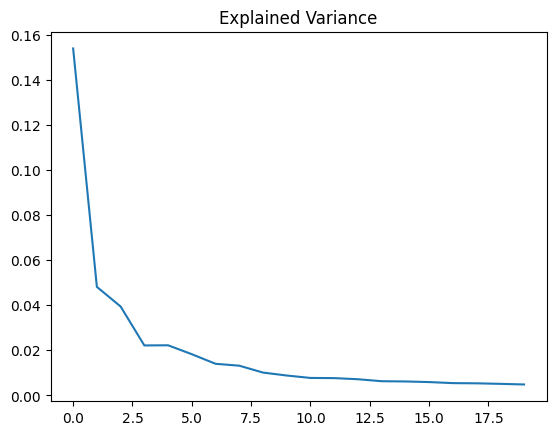

In [9]:
plt.plot(svd.explained_variance_ratio_)
plt.title("Explained Variance")
plt.show()